# TemporalVAE demo notebook with Xiang19 dataset (<A developmental landscape of 3D-cultured human pre-gastrulation embryos>)

## preprocess the orginal data of Xiang19(GEO:GSE136447)

### set up work space

In [51]:
# -*-coding:utf-8 -*-
import sys
print(f"python version: {sys.version}; {sys.executable}")
import os
print(os.getcwd())
os.chdir("/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE")
sys.path.append(os.getcwd())

python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:20:04) [GCC 11.3.0]; /mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/bin/python
/mnt/yijun/nfs_share/awa_project/awa_github/test/TemporalVAE


### import necessary function

In [52]:
from TemporalVAE.utils.utils_project import calHVG_adata as calHVG
from TemporalVAE.utils.utils_project import series_matrix2csv
from TemporalVAE.utils.utils_plot import draw_venn
import anndata as ad
import pandas as pd
# define funtion to get number for strings.
def extract_number(s):
    import re
    match = re.search(r'D(\d+)', s)
    if match:
        return int(match.group(1))
    return None

### `file_path` is the path of orginal dataset, which you download from GEO.

In [53]:
file_path = "/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/data/human_embryo_preimplantation/Xiang2019/"
raw_count = f"{file_path}/GSE136447_555sample_gene_count_matrix.txt"
raw_count = pd.read_csv(raw_count, sep="\t", header=0, index_col=0)
raw_count

,D6N1B23,D6N1B6,D6N1S1,D6N1S15,D6N1S19,D6N1S3,D6N1S33,D6N1S34,D6N1S35,D6N1S39,...,D14_2S1,D14_3B5,D14_3B6,D14_3S10,D14_3S15,D14_3S16,D14_3S9,D14_2S2,D14_2B1,D14_2B3
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000146469.12|VIP,0,0,0,0,0,0,0,0,0,0,...,0,39,67,0,0,0,0,0,0,0
ENSG00000159214.12|CCDC24,0,0,0,0,0,0,453,0,0,0,...,0,0,0,0,2273,0,0,0,1146,5
ENSG00000244171.4|PBX2P1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000136295.14|TTYH3,0,0,0,4,0,0,0,0,0,0,...,2453,1953,2805,2308,0,4,2,395,2428,13430
ENSG00000141736.13|ERBB2,1958,308,5,13,942,321,1376,12,79,1390,...,1052,420,740,1675,9,5,16,518,3179,7347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000155367.15|PPM1J,0,62,0,0,0,0,0,0,0,0,...,0,20,0,459,445,1477,0,0,0,426
ENSG00000172893.15|DHCR7,4362,2620,3589,1612,3482,0,901,31,7782,862,...,969,2477,3023,2267,4185,7411,770,3378,1298,3471
ENSG00000093100.13|AC016026.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Read cell information and trans orginal annotation of cells to more readable ones.

In [54]:
cell_info1 = f"{file_path}/GSE136447-GPL20795_series_matrix.txt"
cell_info1 = series_matrix2csv(cell_info1)

cell_info2 = f"{file_path}/GSE136447-GPL23227_series_matrix.txt"
cell_info2 = series_matrix2csv(cell_info2)

cell_info = pd.concat([cell_info1[1], cell_info2[1]], axis=0)
cell_info['cell_id'] = cell_info['title'].apply(lambda x: x.replace('Embryo_', ""))
# cell_info["development_day"] = cell_info.index.map(extract_number)
# cell_info["time"]=cell_info["development_day"]
cell_info["time"] = cell_info["characteristics_ch1"].apply(lambda x: eval(x.replace(" ", "").replace('age:embryoinvitroday', "")))
cell_info["day"] = cell_info["time"].apply(lambda x: "day" + str(x))
cell_info["cell_type"] = cell_info["characteristics_ch1_2"].apply(lambda x: x.replace(" ", "").replace('celltype:', ""))
cell_info["Stage"] = cell_info["cell_type"]
cell_info = cell_info.set_index("cell_id")
# "day","Stage","n_genes","predicted_time"

if set(cell_info.index) == set(raw_count.columns):
    print("sample id is complete same.")
    raw_count = raw_count.T
    cell_info = cell_info.loc[raw_count.index]
else:
    exit(0)
adata = ad.AnnData(X=raw_count.values, obs=cell_info, var=pd.DataFrame(index=raw_count.columns))
print("Import data, cell number: {}, gene number: {}".format(adata.n_obs, adata.n_vars))
print("Cell number: {}".format(adata.n_obs))
print("Gene number: {}".format(adata.n_vars))
print("Annotation information of data includes: {}".format(adata.obs_keys()))  # 胞注釋信息的keys
print("Cell id first 5: {}".format(adata.obs_names[:5]))  # 返回胞ID 数据类型是object
print("Gene id first 5: {}".format(adata.var_names.to_list()[:5]))  # 返回基因数据类型是list adata.obs.head()# 査看前5行的数据
print("Gene id first 5: {}".format(adata.var.index.to_list()[:5]))

sample id is complete same.
Import data, cell number: 555, gene number: 64837
Cell number: 555
Gene number: 64837
Annotation information of data includes: ['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage']
Cell id first 5: Index(['D6N1B23', 'D6N1B6', 'D6N1S1', 'D6N1S15', 'D6N1S19'], dtype='object')
Gene id first 5: ['ENSG00000146469.12|VIP', 

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_1373546/2996537413.py:24: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=raw_count.values, obs=cell_info, var=pd.DataFrame(index=raw_count.columns))


In [55]:
cell_info

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,...,library_source,library_strategy,relation,relation_2,supplementary_file_1,ID_REF,time,day,cell_type,Stage
D6N1B23,Embryo_D6N1B23,GSM4050151,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050151,6.0,day6.0,ICM,ICM
D6N1B6,Embryo_D6N1B6,GSM4050152,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050152,6.0,day6.0,ICM,ICM
D6N1S1,Embryo_D6N1S1,GSM4050154,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050154,6.0,day6.0,EPI,EPI
D6N1S15,Embryo_D6N1S15,GSM4050153,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050153,6.0,day6.0,EPI,EPI
D6N1S19,Embryo_D6N1S19,GSM4050155,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050155,6.0,day6.0,ICM,ICM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D14_3S16,Embryo_D14_3S16,GSM4050551,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050551,13.5,day13.5,EPI,EPI
D14_3S9,Embryo_D14_3S9,GSM4050552,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050552,13.5,day13.5,CTBs,CTBs
D14_2S2,Embryo_D14_2S2,GSM4050553,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050553,13.5,day13.5,STBs,STBs
D14_2B1,Embryo_D14_2B1,GSM4050554,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,transcriptomic,RNA-Seq,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050554,13.5,day13.5,EVTs,EVTs


In [56]:
adata

AnnData object with n_obs × n_vars = 555 × 64837
    obs: 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage'

### filter low-quality cell and gene and calculate hvgs. Use "cell_range","seurat", and "seurat_v3" to calculate 500 HVGs.

Calculate hvg gene list use cell_ranger method from scanpy.
use hvg method cell_ranger
Calculate hvg gene list use cell_ranger method from scanpy.
use hvg method seurat
Calculate hvg gene list use cell_ranger method from scanpy.
use hvg method seurat_v3


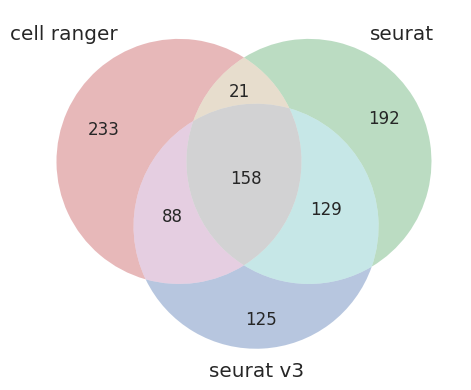

concat all hvg calculated


In [57]:
import scanpy as sc
min_gene_num = 50
min_cell_num = 50
hvg_num = 500
sc.pp.filter_cells(adata, min_genes=min_gene_num)  # drop samples with less than 20 gene expression
sc.pp.filter_genes(adata, min_cells=min_cell_num)

hvg_cellRanger_list = calHVG(adata.copy(), gene_num=hvg_num, method="cell_ranger")
hvg_seurat_list = calHVG(adata.copy(), gene_num=hvg_num, method="seurat")
hvg_seurat_v3_list = calHVG(adata.copy(), gene_num=hvg_num, method="seurat_v3")

draw_venn({"cell ranger": hvg_cellRanger_list, "seurat": hvg_seurat_list, "seurat v3": hvg_seurat_v3_list})
print(f"concat all hvg calculated")

### use genes selected by three methods as final HVGs.

In [58]:
import itertools
combined_hvg_list = list(set(itertools.chain(hvg_cellRanger_list, hvg_seurat_list, hvg_seurat_v3_list)))
filtered_adata_hvg = adata[:, combined_hvg_list].copy()
filtered_adata_hvg

AnnData object with n_obs × n_vars = 555 × 946
    obs: 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage', 'n_genes'
    var: 'n_cells'

### Refilter adata to filter low quality cell and genes.

In [59]:
_shape = filtered_adata_hvg.shape
_new_shape = (0, 0)
min_gene_num = 50
min_cell_num = 50
while _new_shape != _shape:  # make sure drop samples and genes
    _shape = filtered_adata_hvg.shape
    sc.pp.filter_cells(filtered_adata_hvg, min_genes=min_gene_num)  # drop samples with less than 20 gene expression
    sc.pp.filter_genes(filtered_adata_hvg, min_cells=min_cell_num)  # drop genes which none expression in 3 samples
    _new_shape = filtered_adata_hvg.shape
print("Drop cells with less than {} gene expression, "
      "drop genes which none expression in {} samples".format(min_gene_num, min_cell_num))
print("After filter, get cell number: {}, gene number: {}".format(filtered_adata_hvg.n_obs, filtered_adata_hvg.n_vars))
print("the original sc expression anndata should be gene as row, cell as column")
filtered_adata_hvg

Drop cells with less than 50 gene expression, drop genes which none expression in 50 samples
After filter, get cell number: 555, gene number: 946
the original sc expression anndata should be gene as row, cell as column


AnnData object with n_obs × n_vars = 555 × 946
    obs: 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage', 'n_genes'
    var: 'n_cells'

### Some genes have multiple versions, with different versions labeled with "|".
### Such genes were re-labeled with gene names, and the average expression value was denoted as the expression value of the gene

In [60]:
filtered_adata_hvg.var_names = filtered_adata_hvg.var_names.str.split("|").str[-1]

In [61]:
if filtered_adata_hvg.var_names.duplicated().any():
    # 转换为DataFrame，以便使用pandas的groupby功能
    df = pd.DataFrame(filtered_adata_hvg.X, columns=filtered_adata_hvg.var_names)

    # 求每个基因的平均表达量
    df_mean = df.groupby(df.columns, axis=1).mean()

    # 创建一个新的AnnData对象，使用处理后的数据
    filtered_adata_hvg = sc.AnnData(X=df_mean.values, obs=filtered_adata_hvg.obs, var=pd.DataFrame(index=df_mean.columns))
    # filtered_adata_hvg2.var_names_make_unique()
filtered_adata_hvg

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_1373546/1091219846.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_mean = df.groupby(df.columns, axis=1).mean()


AnnData object with n_obs × n_vars = 555 × 945
    obs: 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage', 'n_genes'

### save `filtered_adata_hvg` as .h5ad file.

In [62]:
filtered_adata_hvg.write_h5ad(f"{file_path}/hvg{hvg_num}/adata_hvg.h5ad")
filtered_adata_hvg.obs["dataset_label"] = "xiang2019"
sc_expression_df = pd.DataFrame(data=filtered_adata_hvg.X.T,
                                columns=filtered_adata_hvg.obs.index,
                                index=filtered_adata_hvg.var_names)

... storing 'status' as categorical
... storing 'submission_date' as categorical
... storing 'last_update_date' as categorical
... storing 'type' as categorical
... storing 'channel_count' as categorical
... storing 'source_name_ch1' as categorical
... storing 'organism_ch1' as categorical
... storing 'characteristics_ch1' as categorical
... storing 'characteristics_ch1_2' as categorical
... storing 'growth_protocol_ch1' as categorical
... storing 'molecule_ch1' as categorical
... storing 'extract_protocol_ch1' as categorical
... storing 'extract_protocol_ch1_2' as categorical
... storing 'taxid_ch1' as categorical
... storing 'description' as categorical
... storing 'data_processing' as categorical
... storing 'data_processing_2' as categorical
... storing 'platform_id' as categorical
... storing 'contact_name' as categorical
... storing 'contact_department' as categorical
... storing 'contact_institute' as categorical
... storing 'contact_address' as categorical
... storing 'contact_

### Save raw count data and cell annotation as .csv files.

In [63]:
sc_expression_df.to_csv(f"{file_path}/hvg{hvg_num}/data_count_hvg.csv", sep="\t")
sc_expression_df

,D6N1B23,D6N1B6,D6N1S1,D6N1S15,D6N1S19,D6N1S3,D6N1S33,D6N1S34,D6N1S35,D6N1S39,...,D14_2S1,D14_3B5,D14_3B6,D14_3S10,D14_3S15,D14_3S16,D14_3S9,D14_2S2,D14_2B1,D14_2B3
gene_id,,,,,,,,,,,,,,,,,,,,,
AADAT,446.0,1099.0,0.0,925.0,0.0,868.0,0.0,5.0,0.0,0.0,...,842.0,3535.0,11491.0,0.0,6762.0,333.0,5.0,815.0,1964.0,1150.0
AASS,905.0,977.0,4.0,123.0,282.0,0.0,1849.0,5521.0,2083.0,0.0,...,157.0,10.0,0.0,37470.0,63071.0,9046.0,0.0,376.0,0.0,482.0
ABCG2,6244.0,1105.0,0.0,0.0,15935.0,0.0,0.0,0.0,2567.0,0.0,...,36342.0,39683.0,44536.0,5.0,0.0,4.0,31091.0,6813.0,835.0,50667.0
ABI3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2936.0,0.0,0.0,0.0,0.0,0.0,0.0
ABI3BP,0.0,708.0,0.0,5202.0,0.0,1560.0,2593.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF468,5779.0,382.0,7056.0,77.0,8155.0,10071.0,16.0,51.0,1535.0,17429.0,...,891.0,8361.0,50.0,7739.0,11663.0,5.0,23472.0,4445.0,14.0,105.0
ZNF702P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,...,1349.0,4007.0,1358.0,30.0,8.0,2.0,0.0,135.0,4174.0,3410.0
ZNF750,2154.0,879.0,0.0,0.0,6.0,24.0,0.0,0.0,0.0,0.0,...,3114.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.0,0.0


In [64]:
filtered_adata_hvg.obs.to_csv(f"{file_path}/hvg{hvg_num}/cell_with_time.csv", sep="\t")
filtered_adata_hvg.var.to_csv(f"{file_path}/hvg{hvg_num}/gene_info.csv", sep="\t")
print("After filter, get cell number: {}, gene number: {}".format(filtered_adata_hvg.n_obs, filtered_adata_hvg.n_vars))
filtered_adata_hvg

After filter, get cell number: 555, gene number: 945


AnnData object with n_obs × n_vars = 555 × 945
    obs: 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'extract_protocol_ch1_2', 'taxid_ch1', 'description', 'data_processing', 'data_processing_2', 'platform_id', 'contact_name', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'data_row_count', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'relation_2', 'supplementary_file_1', 'ID_REF', 'time', 'day', 'cell_type', 'Stage', 'n_genes', 'dataset_label'

In [65]:
print(f"{file_path}/hvg{hvg_num}/")

/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/data/human_embryo_preimplantation/Xiang2019//hvg500/


## Start Train and test TemporalVAE on Xiang19 data

### Set up work space and import necessary function and package.

In [66]:
import torch

torch.set_float32_matmul_precision('high')
# import pyro
import logging
from TemporalVAE.utils.logging_system import LogHelper

# smoke_test = ('CI' in os.environ)  # ignore; used to check code integrity in the Pyro repo
# assert pyro.__version__.startswith('1.8.5')
# pyro.set_rng_seed(1)
from TemporalVAE.utils.utils_project import preprocessData_and_dropout_some_donor_or_gene, Embryodonor_resort_key, onlyTrain_model
from TemporalVAE.utils.utils_project import denormalize, task_kFoldTest
from TemporalVAE.utils.utils_plot import plt_umap_byScanpy
from collections import Counter
import yaml
import argparse
import anndata as ad
import numpy as np
import pandas as pd

### Set result and logger save path.

In [67]:
result_save_path = f'{os.getcwd()}/examples/humanEmbryo_xiang2019/'
if not os.path.exists(result_save_path):
    os.makedirs(result_save_path)
# ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
logger_file = f'{result_save_path}/humanEmbryo_xiang2019.log'
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)

### preprocess data

In [68]:
# ------------ Preprocess data, with hvg gene from preprocess_data_mouse_embryonic_development.py------------------------
time_standard_type = "embryoneg5to5"
sc_data_file_csv = "/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/data/human_embryo_preimplantation/Xiang2019/hvg500/data_count_hvg.csv"
cell_info_file_csv =  "/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/data/human_embryo_preimplantation/Xiang2019//hvg500//cell_with_time.csv"
sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene("", sc_data_file_csv, cell_info_file_csv,
                                                                            # donor_attr=donor_attr, drop_out_donor=drop_out_donor,
                                                                            min_cell_num=50,
                                                                            min_gene_num=50,
                                                                            data_raw_count_bool=True)  # 2024-04-20 15:38:58
special_path_str = ""

2025-07-09 13:30:37,228 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2025-07-09 13:30:37,228 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2025-07-09 13:30:37,228 INFO - TemporalVAE.utils.utils_project - the original sc expression anndata should be gene as row, cell as column 
2025-07-09 13:30:37,234 INFO - TemporalVAE.utils.utils_project - input data is .csv file, where gene as row, cell as column. 
2025-07-09 13:30:37,234 INFO - TemporalVAE.utils.utils_project - input data is .csv file, where gene as row, cell as column. 
2025-07-09 13:30:37,234 INFO - TemporalVAE.utils.utils_project - input data is .csv file, where gene as row, cell as column. 
2025-07-09 13:30:37,464 INFO - TemporalVAE.utils.utils_project - read the original sc expression anndata with shape (gene, cell): (945, 555) 
2025-07-09 13:30:37,464 INFO - TemporalVAE.utils.utils_project 

normalized sample to 1000000.0
Input data is raw count, do the log1p().


2025-07-09 13:30:37,844 INFO - TemporalVAE.utils.utils_project - save preprocessed_cell_info.csv and preprocessed_gene_info.csv at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/ 
2025-07-09 13:30:37,844 INFO - TemporalVAE.utils.utils_project - save preprocessed_cell_info.csv and preprocessed_gene_info.csv at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/ 
2025-07-09 13:30:37,844 INFO - TemporalVAE.utils.utils_project - save preprocessed_cell_info.csv and preprocessed_gene_info.csv at /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/ 


In [69]:
sc_expression_df

,AADAT,AASS,ABCG2,ABI3,ABI3BP,ABRA,AC004754.1,AC004870.1,AC005899.8,AC008012.1,...,ZIC3,ZNF114,ZNF280A,ZNF292,ZNF296,ZNF468,ZNF702P,ZNF750,ZSCAN10,ZSCAN4
D6N1B23,0.768123,0.759304,0.704098,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.586476,-1.001023,-0.523737,-1.609120,0.641682,1.076652,-1.566551,1.175830,-0.189059,-0.409224
D6N1B6,1.222415,0.902912,0.187845,-0.263679,5.734759,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.140831,0.768706,-0.523737,0.532179,1.075717,-0.033983,-1.566551,0.999126,0.993866,-0.409224
D6N1S1,-1.136359,-0.793219,-2.214447,-0.263679,-0.279015,-0.261942,-0.217034,0.530094,-0.390292,-0.302179,...,-0.586476,-0.948890,-0.523737,-2.157164,-1.393025,1.450700,-1.566551,-0.994867,-0.713960,-0.409224
D6N1S15,1.315319,0.342062,-2.214447,-0.263679,8.155582,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,1.958856,1.011805,-0.523737,-2.382791,1.407074,-0.580176,-1.566551,-0.994867,2.162210,-0.409224
D6N1S19,-1.136359,0.461630,1.161769,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.586476,-1.459395,-0.523737,-0.952389,0.958691,1.375325,-1.566551,-0.529934,-0.265736,-0.409224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D14_3S16,0.485519,1.380036,-1.956501,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,1.823105,-1.459395,-0.523737,-2.733285,-1.393025,-2.183015,-1.424852,-0.994867,-0.081709,-0.409224
D14_3S9,-0.862659,-1.264213,1.077416,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.586476,-1.459395,-0.523737,0.225571,0.923014,1.451346,-1.566551,-0.994867,-0.713960,-0.409224
D14_2S2,0.804744,0.289404,0.549667,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.586476,-0.170511,-0.523737,-0.894034,-1.393025,0.718314,-0.331464,-0.994867,-0.713960,0.093271
D14_2B1,0.654358,-1.264213,-0.706892,-0.263679,-0.279015,-0.261942,-0.217034,-0.337470,-0.390292,-0.302179,...,-0.586476,-1.459395,-0.300657,-1.434894,-1.393025,-2.251147,0.406965,-0.413979,-0.713960,-0.409224


In [70]:
cell_time

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,...,relation,relation_2,supplementary_file_1,ID_REF,time,day,cell_type,Stage,n_genes,dataset_label
D6N1B23,Embryo_D6N1B23,GSM4050151,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050151,6.0,day6.0,ICM,ICM,428,xiang2019
D6N1B6,Embryo_D6N1B6,GSM4050152,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050152,6.0,day6.0,ICM,ICM,489,xiang2019
D6N1S1,Embryo_D6N1S1,GSM4050154,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050154,6.0,day6.0,EPI,EPI,392,xiang2019
D6N1S15,Embryo_D6N1S15,GSM4050153,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050153,6.0,day6.0,EPI,EPI,402,xiang2019
D6N1S19,Embryo_D6N1S19,GSM4050155,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050155,6.0,day6.0,ICM,ICM,418,xiang2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D14_3S16,Embryo_D14_3S16,GSM4050551,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050551,13.5,day13.5,EPI,EPI,412,xiang2019
D14_3S9,Embryo_D14_3S9,GSM4050552,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050552,13.5,day13.5,CTBs,CTBs,419,xiang2019
D14_2S2,Embryo_D14_2S2,GSM4050553,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050553,13.5,day13.5,STBs,STBs,509,xiang2019
D14_2B1,Embryo_D14_2B1,GSM4050554,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050554,13.5,day13.5,EVTs,EVTs,531,xiang2019


### set donor list and dictionary

In [71]:
# ---------------------------------------- set donor list and dictionary -----------------------------------------------------
donor_list = np.unique(cell_time["day"])
donor_list = sorted(donor_list, key=Embryodonor_resort_key)
donor_dic = dict()
for i in range(len(donor_list)):
    donor_dic[donor_list[i]] = i
batch_dic = donor_dic.copy()
_logger.info("Consider donor as batch effect, donor use label: {}".format(donor_dic))
_logger.info("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["day"])))
save_file_name = f"{_logger.root.handlers[0].baseFilename.replace('.log', '')}/"
save_file_name

2025-07-09 13:30:40,895 INFO - __main__ - Consider donor as batch effect, donor use label: {'day10.0': 0, 'day12.0': 1, 'day13.5': 2, 'day14.0': 3, 'day6.0': 4, 'day7.0': 5, 'day8.0': 6, 'day9.0': 7} 
2025-07-09 13:30:40,895 INFO - __main__ - Consider donor as batch effect, donor use label: {'day10.0': 0, 'day12.0': 1, 'day13.5': 2, 'day14.0': 3, 'day6.0': 4, 'day7.0': 5, 'day8.0': 6, 'day9.0': 7} 
2025-07-09 13:30:40,895 INFO - __main__ - Consider donor as batch effect, donor use label: {'day10.0': 0, 'day12.0': 1, 'day13.5': 2, 'day14.0': 3, 'day6.0': 4, 'day7.0': 5, 'day8.0': 6, 'day9.0': 7} 
2025-07-09 13:30:40,930 INFO - __main__ - For each donor (donor_id, cell_num):Counter({'day14.0': 120, 'day12.0': 88, 'day10.0': 77, 'day9.0': 68, 'day7.0': 65, 'day6.0': 63, 'day8.0': 59, 'day13.5': 15})  
2025-07-09 13:30:40,930 INFO - __main__ - For each donor (donor_id, cell_num):Counter({'day14.0': 120, 'day12.0': 88, 'day10.0': 77, 'day9.0': 68, 'day7.0': 65, 'day6.0': 63, 'day8.0': 59, '

'/mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/'

## Set model config

In [72]:
# ------- set config and logger ------
with open("vae_model_configs/supervise_vae_regressionclfdecoder_exp2_toyDataset.yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

### If you have a donor you want to exclude from the calculation, please set its name to `drop_out_donor`. If you don't have any donor to exclude, just set `drop_out_donor=""`

In [73]:
drop_out_donor = ""
print(f"drop the donor: {drop_out_donor}")
cell_drop_index_list = cell_time.loc[cell_time["dataset_label"] == drop_out_donor].index
cell_drop_index_list

drop the donor: 


Index([], dtype='object')

In [74]:
sc_expression_df_filter = sc_expression_df.drop(cell_drop_index_list, axis=0)
cell_time_filter = cell_time.drop(cell_drop_index_list, axis=0)
cell_time_filter = cell_time_filter.loc[sc_expression_df_filter.index]
cell_time_filter

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,...,relation,relation_2,supplementary_file_1,ID_REF,time,day,cell_type,Stage,n_genes,dataset_label
D6N1B23,Embryo_D6N1B23,GSM4050151,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050151,6.0,day6.0,ICM,ICM,428,xiang2019
D6N1B6,Embryo_D6N1B6,GSM4050152,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050152,6.0,day6.0,ICM,ICM,489,xiang2019
D6N1S1,Embryo_D6N1S1,GSM4050154,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050154,6.0,day6.0,EPI,EPI,392,xiang2019
D6N1S15,Embryo_D6N1S15,GSM4050153,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050153,6.0,day6.0,EPI,EPI,402,xiang2019
D6N1S19,Embryo_D6N1S19,GSM4050155,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 6,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050155,6.0,day6.0,ICM,ICM,418,xiang2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D14_3S16,Embryo_D14_3S16,GSM4050551,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050551,13.5,day13.5,EPI,EPI,412,xiang2019
D14_3S9,Embryo_D14_3S9,GSM4050552,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050552,13.5,day13.5,CTBs,CTBs,419,xiang2019
D14_2S2,Embryo_D14_2S2,GSM4050553,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050553,13.5,day13.5,STBs,STBs,509,xiang2019
D14_2B1,Embryo_D14_2B1,GSM4050554,Public on Nov 26 2019,Aug 27 2019,Oct 05 2021,SRA,1,embryo,Homo sapiens,age: embryo invitro day 13.5,...,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,GSM4050554,13.5,day13.5,EVTs,EVTs,531,xiang2019


## 1. If you want to do train on all donors and check the umap of latent space.

2025-07-09 13:30:42,413 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([945, 555]) 
2025-07-09 13:30:42,413 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([945, 555]) 
2025-07-09 13:30:42,413 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([945, 555]) 
2025-07-09 13:30:42,458 INFO - TemporalVAE.utils.utils_project - label dictionary: {600: -5.0, 650: -4.375, 700: -3.75, 750: -3.125, 800: -2.5, 850: -1.875, 900: -1.25, 950: -0.625, 1000: 0.0, 1050: 0.625, 1100: 1.25, 1150: 1.875, 1200: 2.5, 1250: 3.125, 1300: 3.75, 1350: 4.375, 1400: 5.0} 
2025-07-09 13:30:42,458 INFO - TemporalVAE.utils.utils_project - label dictionary: {600: -5.0, 650: -4.375, 700: -3.75, 750: -3.125, 800: -2.5, 850: -1.875, 900: -1.25, 950: -0.625, 1000: 0.0, 1050: 0.625, 1100: 1.25, 1150: 1.875, 1200: 2.5, 1250: 3.125, 1300: 3.75, 1350: 4.375, 1400: 5.0} 
2025-07-09 

Free Memory Percentage: 48.08%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 32.35GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 36.735GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 18.106GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 36.735GB
======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(64.2751, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.3874, device='cuda:1'), 'train_KLD_step': tensor(-7.0603, device='cuda:1'), 'train_clf_loss_step': tensor(12.5772, device='cuda:1'), 'train_loss_epoch': tensor(64.2751, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.3874, device='cuda:1'), 'train_KLD_epoch': tensor(-7.0603, device='cuda:1'), 'train_clf_loss_epoch': tensor(12.5772, device='cuda:1')}
Epoch train loss: {'train_loss_step': tensor(59.9861, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.3455, device='cuda:1'), 'train_KLD_step': tensor(-7.9449, device='cuda:1'), 'train_clf_loss_step': tensor(11.7277, device='cuda:1'), 'train_loss_epoch': tensor(59.9861, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.3455, device='cuda:1'), 'train_KLD_epoch': tensor(-7.9449, device='cuda:1'), 'train_clf_loss_epoch': tensor(11.7277, device='cuda:1')}
Epoch train loss: {'train_loss_step': 

2025-07-09 13:31:39,185 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=70` reached. 
2025-07-09 13:31:39,185 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=70` reached. 
2025-07-09 13:31:39,185 INFO - pytorch_lightning.utilities.rank_zero - `Trainer.fit` stopped: `max_epochs=70` reached. 
2025-07-09 13:31:39,307 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:31:39,307 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2025-07-09 13:31:39,307 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/envs/TemporalVAE-V1.0/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `

Predicting: 0it [00:00, ?it/s]

2025-07-09 13:31:39,478 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-09 13:31:39,478 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-09 13:31:39,478 INFO - TemporalVAE.utils.utils_project - Plot training loss line for check. 
2025-07-09 13:31:39,515 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:39,515 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:39,515 INFO - tensorboard - No path found after 

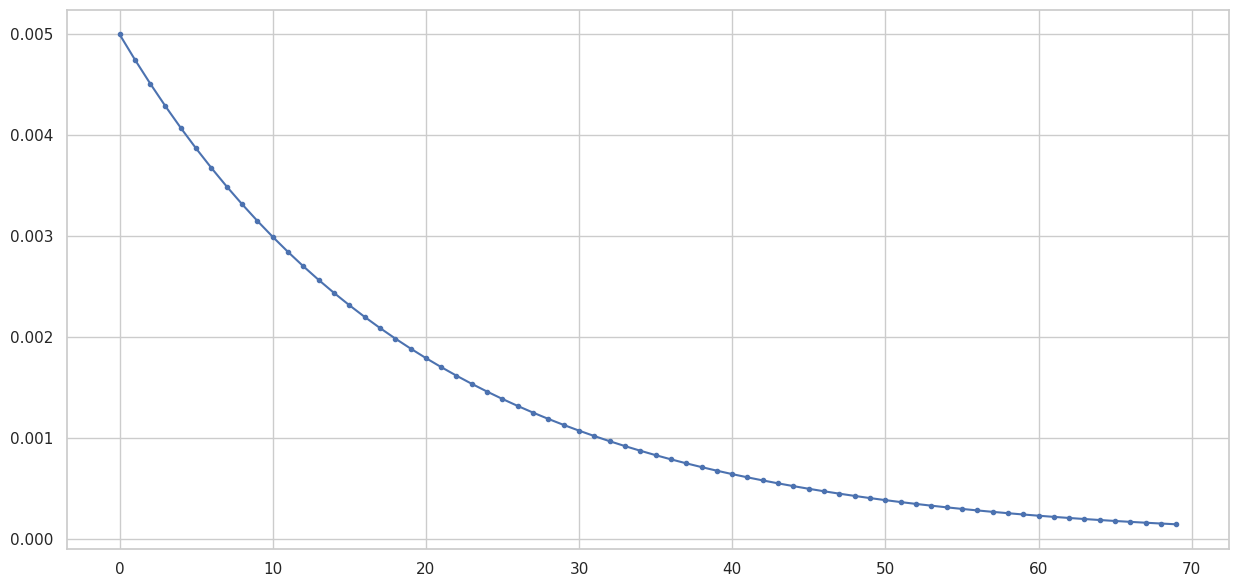

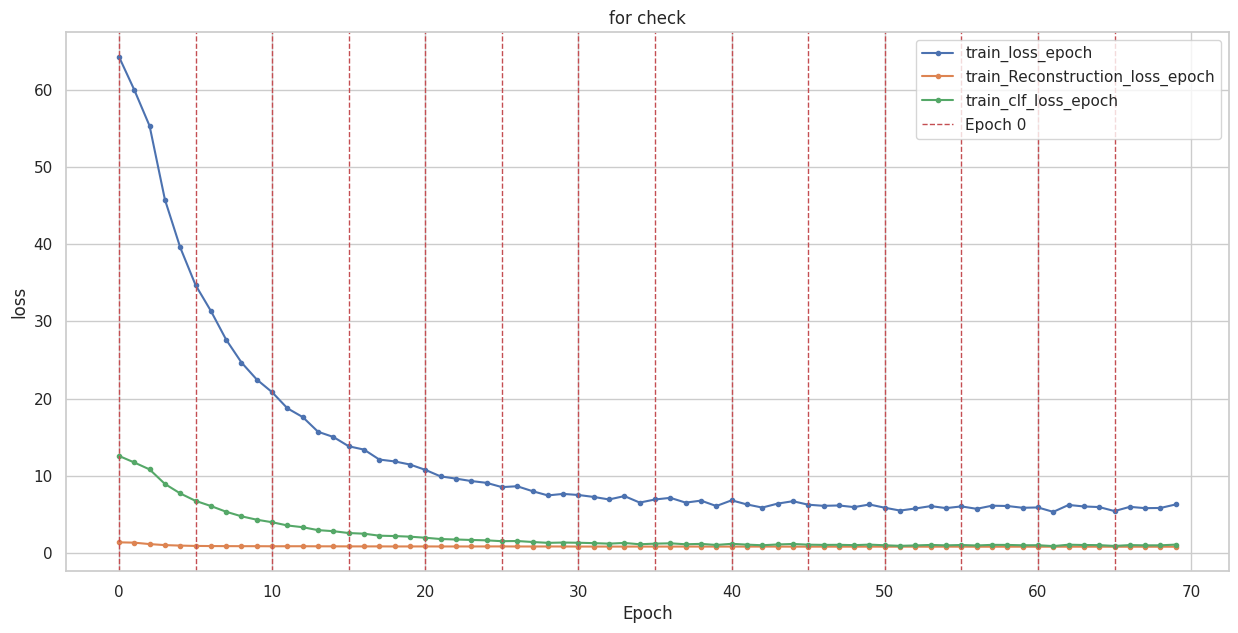

2025-07-09 13:31:41,065 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,065 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,065 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,089 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:41,089 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:41,089 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/T

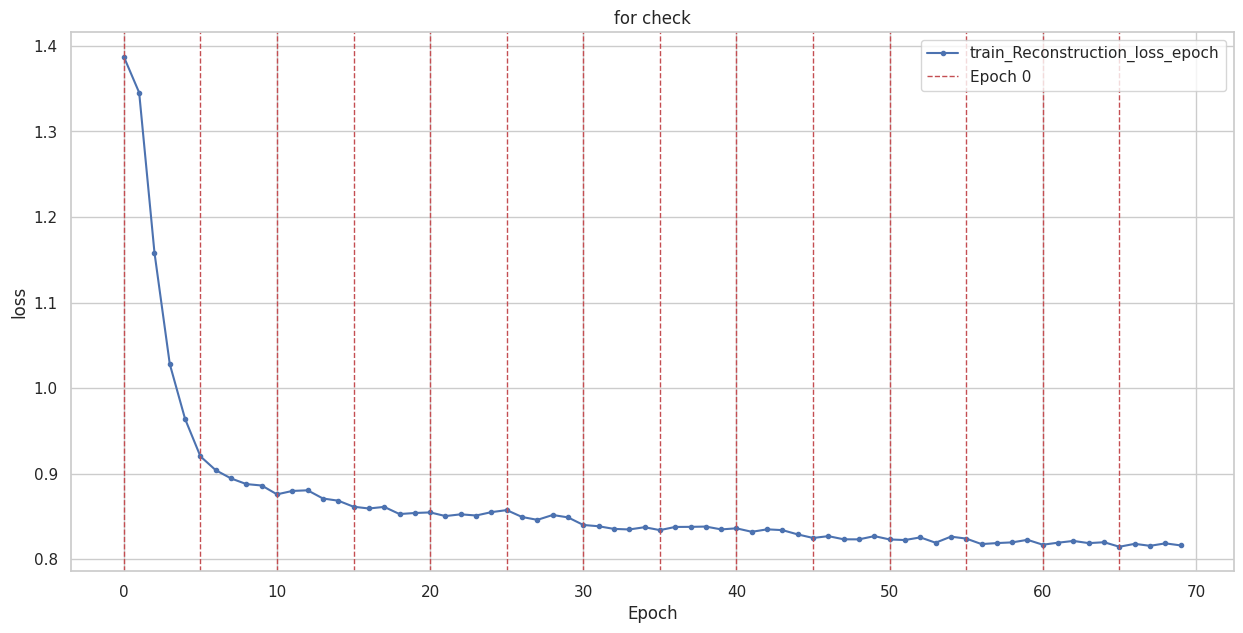

2025-07-09 13:31:41,498 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,498 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,498 INFO - TemporalVAE.utils.utils_plot - plot training process. 
2025-07-09 13:31:41,522 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:41,522 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019/wholeData/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_3/events.out.tfevents.1752085842.GPU2.1373546.17 
2025-07-09 13:31:41,522 INFO - tensorboard - No path found after /mnt/yijun/nfs_share/awa_project/awa_github/T

<Figure size 1500x700 with 0 Axes>

In [75]:
train_epoch_num=70
sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, _m, train_clf_result, label_dic, total_result = onlyTrain_model(
    sc_expression_df_filter, donor_dic,
    special_path_str,
    cell_time_filter,
    time_standard_type, config, train_epoch_num,
     plot_latentSpaceUmap=False, plot_trainingLossLine=True, time_saved_asFloat=True, batch_dic=batch_dic, donor_str="day",
    )

... storing 'dataset_label' as categorical
... storing 'cell_type' as categorical
... storing 'day' as categorical


latent mu save as /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019//n50_latent_mu.h5ad


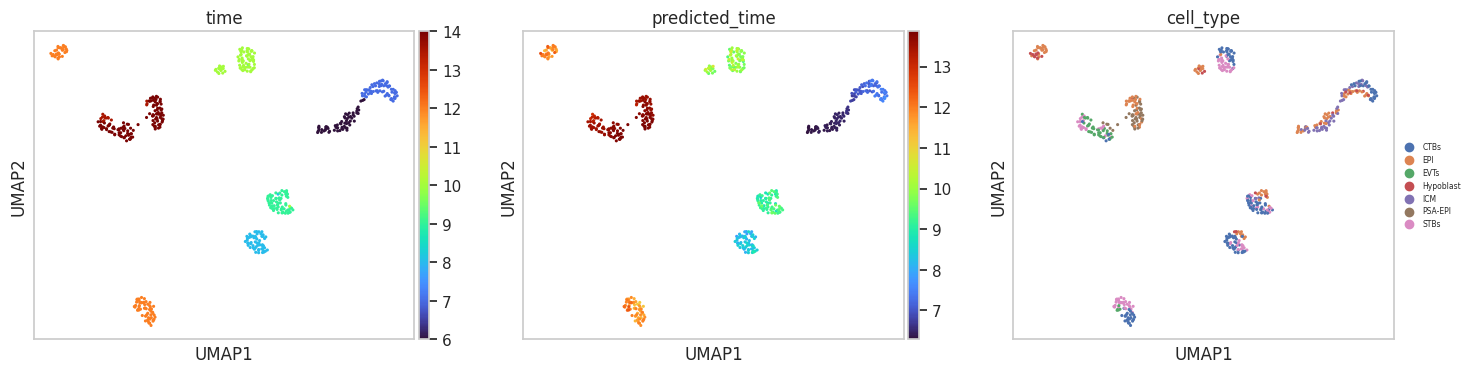

figure save as /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE-release-main/examples/humanEmbryo_xiang2019/humanEmbryo_xiang2019//n50_latentSpace_umap_byScanpy.png


AnnData object with n_obs × n_vars = 555 × 50
    obs: 'time', 'predicted_time', 'dataset_label', 'cell_type', 'day'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [76]:
predict_donors_df = pd.DataFrame(train_clf_result, columns=["pseudotime"], index=cell_time_filter.index)
predict_donors_df['predicted_time'] = predict_donors_df['pseudotime'].apply(denormalize, args=(min(label_dic.keys()) / 100, max(label_dic.keys()) / 100,
                                                                                               min(label_dic.values()), max(label_dic.values())))
cell_time_filter = pd.concat([cell_time_filter, predict_donors_df], axis=1)

plt_image_adata = ad.AnnData(X=total_result["mu"].cpu().numpy())
plt_image_adata.obs = cell_time_filter[["time", "predicted_time", "dataset_label", "cell_type", "day"]]

plt_umap_byScanpy(plt_image_adata.copy(),
                  ["time", "predicted_time", "cell_type"],
                  save_path=save_file_name, mode=None, figure_size=(5, 4),
                  color_map="turbo",
                  n_neighbors=80, n_pcs=10, special_file_name_str="n50_")

## If you want to do multiple loop calculations: test on one donor and train on other donors.

In [ ]:
predict_donors_dic, label_dic = task_kFoldTest(donor_list, sc_expression_df, donor_dic, batch_dic, special_path_str, cell_time, time_standard_type,
                                               config, train_epoch_num, _logger, donor_str="day", batch_size=100000, cmap_color="turbo")

_logger.info("Finish fold-test.")

2025-07-09 13:31:44,861 INFO - __main__ - start task: k-fold test with ['day10.0', 'day12.0', 'day13.5', 'day14.0', 'day6.0', 'day7.0', 'day8.0', 'day9.0']. 
2025-07-09 13:31:44,861 INFO - __main__ - start task: k-fold test with ['day10.0', 'day12.0', 'day13.5', 'day14.0', 'day6.0', 'day7.0', 'day8.0', 'day9.0']. 
2025-07-09 13:31:44,861 INFO - __main__ - start task: k-fold test with ['day10.0', 'day12.0', 'day13.5', 'day14.0', 'day6.0', 'day7.0', 'day8.0', 'day9.0']. 
2025-07-09 13:31:45,155 INFO - TemporalVAE.utils.utils_project - the 1/8 fold train, use donor-day10.0 as test set 
2025-07-09 13:31:45,155 INFO - TemporalVAE.utils.utils_project - the 1/8 fold train, use donor-day10.0 as test set 
2025-07-09 13:31:45,155 INFO - TemporalVAE.utils.utils_project - the 1/8 fold train, use donor-day10.0 as test set 
2025-07-09 13:31:45,176 INFO - TemporalVAE.utils.utils_project - Set x_sc_train data with shape (gene, cells): torch.Size([945, 478]) 
2025-07-09 13:31:45,176 INFO - TemporalVAE.

Free Memory Percentage: 53.20%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 32.35GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 36.731GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 18.106GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 36.731GB


2025-07-09 13:31:45,519 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:31:45,519 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:31:45,519 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2025-07-09 13:31:45,520 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:31:45,520 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:31:45,520 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2025-07-09 13:31:45,522 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-09 13:31:45,522 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025-07-09 13:31:45,522 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2025

======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


Sanity Checking: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(61.8026, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.1409, device='cuda:1'), 'train_KLD_step': tensor(-9.5069, device='cuda:1'), 'train_clf_loss_step': tensor(12.1319, device='cuda:1'), 'val_loss': tensor(1.1697, device='cuda:1'), 'val_Reconstruction_loss': tensor(0.7721, device='cuda:1'), 'val_KLD': tensor(-5.0015, device='cuda:1'), 'val_clf_loss': tensor(0.0793, device='cuda:1'), 'train_loss_epoch': tensor(61.8026, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.1409, device='cuda:1'), 'train_KLD_epoch': tensor(-9.5069, device='cuda:1'), 'train_clf_loss_epoch': tensor(12.1319, device='cuda:1')}


Validation: 0it [00:00, ?it/s]

Epoch train loss: {'train_loss_step': tensor(53.1480, device='cuda:1'), 'train_Reconstruction_loss_step': tensor(1.0122, device='cuda:1'), 'train_KLD_step': tensor(-11.6688, device='cuda:1'), 'train_clf_loss_step': tensor(10.4266, device='cuda:1'), 'val_loss': tensor(2.9103, device='cuda:1'), 'val_Reconstruction_loss': tensor(0.8138, device='cuda:1'), 'val_KLD': tensor(-17.1824, device='cuda:1'), 'val_clf_loss': tensor(0.4184, device='cuda:1'), 'train_loss_epoch': tensor(53.1480, device='cuda:1'), 'train_Reconstruction_loss_epoch': tensor(1.0122, device='cuda:1'), 'train_KLD_epoch': tensor(-11.6688, device='cuda:1'), 'train_clf_loss_epoch': tensor(10.4266, device='cuda:1')}


Validation: 0it [00:00, ?it/s]